## Classification Exploration 5: Support Vector Machine

# [Classification: Support Vector Machine](https://en.wikipedia.org/wiki/Support_vector_machine)

The IBM HR Analytics Employee Attrition dataset contains fictional data created by IBM data scientists. 
It includes 1,470 employee records with 35 features covering demographics, job roles, satisfaction levels, 
and compensation. The target variable is **Attrition** — whether an employee left the company (Yes/No).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
%matplotlib inline

df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Drop constant columns
df = df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18'])

# Encode categorical columns
df = pd.get_dummies(df, columns=['BusinessTravel', 'Department', 'EducationField',
                                  'Gender', 'JobRole', 'MaritalStatus', 'OverTime'],
                    drop_first=True)

# Encode target variable
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [2]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Attrition'])
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                     test_size=0.30,
                                                     stratify=y,
                                                     random_state=123)

print(X_train.shape, X_test.shape)

(1029, 44) (441, 44)


In [3]:
# Scale data — SVM is sensitive to feature magnitudes
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X)

scaled_X_train = pd.DataFrame(scaler.transform(X_train.astype(float)), columns=X_train.columns)
scaled_X_test = pd.DataFrame(scaler.transform(X_test.astype(float)), columns=X_test.columns)

# SVM Model

In [4]:
from sklearn.svm import SVC

model = SVC(kernel='sigmoid', C=1)
model.fit(scaled_X_train, y_train)
model.predict(scaled_X_test)

# C: penalty parameter — higher C = less regularization
# kernel: 'linear', 'poly', 'rbf', 'sigmoid'
# degree: degree of polynomial kernel (only for 'poly')
# gamma: kernel coefficient for 'rbf', 'poly', 'sigmoid'

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [5]:
#DEFINE YOUR CLASSIFIER and THE PARAMETERS GRID
classifier = SVC()
parameters = {
    "kernel": ['linear', 'rbf', 'poly'],
    "C": [.01, .1, 1],
    "gamma": [1],
    "degree": [2, 3, 4]  # only used with 'poly' kernel
}

In [6]:
#DEFINE YOUR GRIDSEARCH
from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(classifier, parameters, cv=3, scoring='f1', verbose=50, n_jobs=-1, refit=True)

In [7]:
#TRAIN YOUR CLASSIFIER
gs = gs.fit(scaled_X_train, y_train)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
[CV 1/3; 1/27] START C=0.01, degree=2, gamma=1, kernel=linear...................
[CV 2/3; 1/27] START C=0.01, degree=2, gamma=1, kernel=linear...................
[CV 3/3; 1/27] START C=0.01, degree=2, gamma=1, kernel=linear...................
[CV 1/3; 1/27] END C=0.01, degree=2, gamma=1, kernel=linear;, score=0.000 total time=   0.0s
[CV 2/3; 1/27] END C=0.01, degree=2, gamma=1, kernel=linear;, score=0.000 total time=   0.0s
[CV 3/3; 1/27] END C=0.01, degree=2, gamma=1, kernel=linear;, score=0.000 total time=   0.0s
[CV 2/3; 2/27] START C=0.01, degree=2, gamma=1, kernel=rbf......................
[CV 2/3; 3/27] START C=0.01, degree=2, gamma=1, kernel=poly.....................
[CV 1/3; 2/27] START C=0.01, degree=2, gamma=1, kernel=rbf......................
[CV 1/3; 3/27] START C=0.01, degree=2, gamma=1, kernel=poly.....................
[CV 2/3; 3/27] END C=0.01, degree=2, gamma=1, kernel=poly;, score=0.222 total time=   0.0s
[C

In [8]:
print('***GRIDSEARCH RESULTS***')
print("Best score: %f using %s" % (gs.best_score_, gs.best_params_))

means = gs.cv_results_['mean_test_score']
stds = gs.cv_results_['std_test_score']
params = gs.cv_results_['params']

for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

***GRIDSEARCH RESULTS***
Best score: 0.456517 using {'C': 1, 'degree': 2, 'gamma': 1, 'kernel': 'linear'}
0.000000 (0.000000) with: {'C': 0.01, 'degree': 2, 'gamma': 1, 'kernel': 'linear'}
0.000000 (0.000000) with: {'C': 0.01, 'degree': 2, 'gamma': 1, 'kernel': 'rbf'}
0.299982 (0.057100) with: {'C': 0.01, 'degree': 2, 'gamma': 1, 'kernel': 'poly'}
0.000000 (0.000000) with: {'C': 0.01, 'degree': 3, 'gamma': 1, 'kernel': 'linear'}
0.000000 (0.000000) with: {'C': 0.01, 'degree': 3, 'gamma': 1, 'kernel': 'rbf'}
0.325039 (0.028218) with: {'C': 0.01, 'degree': 3, 'gamma': 1, 'kernel': 'poly'}
0.000000 (0.000000) with: {'C': 0.01, 'degree': 4, 'gamma': 1, 'kernel': 'linear'}
0.000000 (0.000000) with: {'C': 0.01, 'degree': 4, 'gamma': 1, 'kernel': 'rbf'}
0.178982 (0.033968) with: {'C': 0.01, 'degree': 4, 'gamma': 1, 'kernel': 'poly'}
0.438617 (0.077594) with: {'C': 0.1, 'degree': 2, 'gamma': 1, 'kernel': 'linear'}
0.000000 (0.000000) with: {'C': 0.1, 'degree': 2, 'gamma': 1, 'kernel': 'rbf'}
0

In [9]:
#TEST ON YOUR TEST SET
best_model = gs.best_estimator_
y_pred = best_model.predict(scaled_X_test)
y_pred_train = best_model.predict(scaled_X_train)

In [10]:
from sklearn.metrics import f1_score

print('***RESULTS ON TRAIN SET***')
print("f1_score: ", f1_score(y_train, y_pred_train))
print("--")
print('***RESULTS ON TEST SET***')
print("f1_score: ", f1_score(y_test, y_pred))

***RESULTS ON TRAIN SET***
f1_score:  0.5517241379310345
--
***RESULTS ON TEST SET***
f1_score:  0.5982905982905983


In [11]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       370
           1       0.76      0.49      0.60        71

    accuracy                           0.89       441
   macro avg       0.83      0.73      0.77       441
weighted avg       0.89      0.89      0.88       441



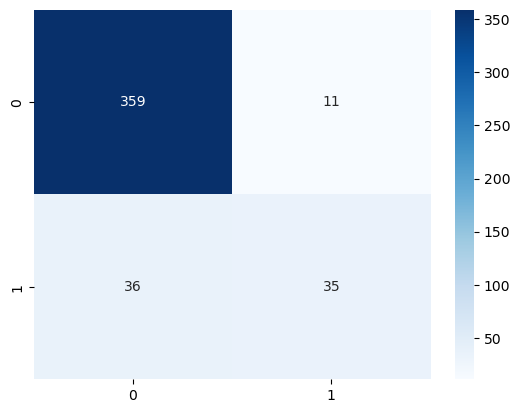

In [12]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues")
plt.show()

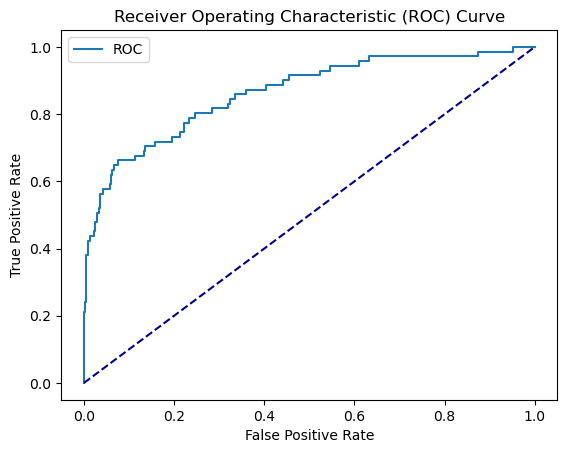

AUC: 0.86


In [13]:
from sklearn import metrics

model = SVC(C=1, kernel='linear', probability=True)
model.fit(scaled_X_train, y_train)
y_pred = model.predict(scaled_X_test)

y_probs = model.predict_proba(scaled_X_test)

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_probs[:, 1])

plt.plot(fpr, tpr, label='ROC')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

auc = metrics.roc_auc_score(y_test, y_probs[:, 1])
print('AUC: %.2f' % auc)

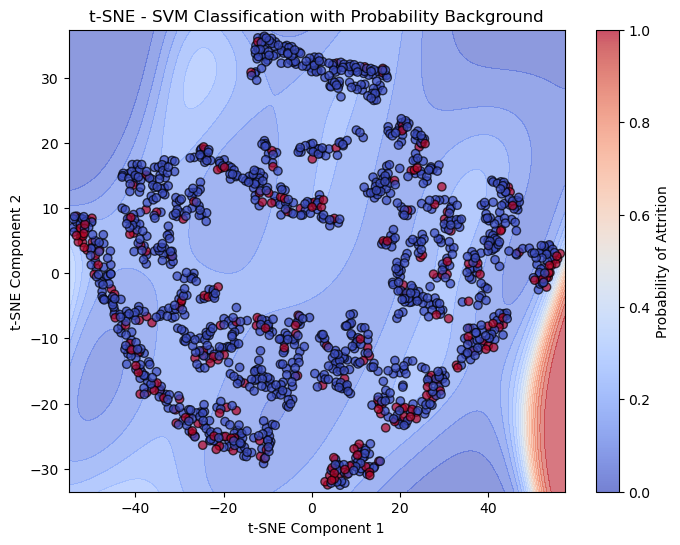

In [14]:
import numpy as np
from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

# Apply t-SNE with 2 components
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

# Train SVM on t-SNE transformed data
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_tsne, y)

# Create mesh grid
x_min, x_max = X_tsne[:, 0].min() - 1, X_tsne[:, 0].max() + 1
y_min, y_max = X_tsne[:, 1].min() - 1, X_tsne[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

# Compute probability of class 1 for each grid point
Z = svm.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=20, cmap="coolwarm", alpha=0.6)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="coolwarm", edgecolors="k", alpha=0.7)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE - SVM Classification with Probability Background")
plt.colorbar(label="Probability of Attrition")
plt.show()

## Summary

In this notebook we applied a Support Vector Machine classifier to predict employee attrition using the IBM HR dataset.

SVM with a linear kernel matched Logistic Regression almost exactly:

- **F1 train = 0.55, F1 test = 0.60** — no overfitting, test slightly outperforms train
- **AUC = 0.86** — tied with Logistic Regression

Updated leaderboard:

| Model | F1 Test | AUC |
|-------|---------|-----|
| KNN | 0.22 | 0.54 |
| Decision Tree | 0.44 | 0.69 |
| Naive Bayes | 0.44 | 0.74 |
| Logistic Regression | 0.61 | 0.86 |
| SVM | 0.60 | 0.86 |

Key findings from the GridSearch:
- **Linear kernel** performed best — consistent with Logistic Regression's strong performance, suggesting the data is largely linearly separable
- **RBF kernel scored 0.0** across all C values — gamma=1 was too aggressive, collapsing all predictions to the majority class
- **Poly kernel** was decent but below linear

The t-SNE visualization revealed that the data forms a complex ring-like structure with attrition cases scattered throughout all clusters — explaining why no model has been able to push F1 significantly above 0.60.

The final notebooks will explore ensemble methods (Random Forest, XGBoost) which may be able to capture these complex local patterns better than linear models.